# Fixed Calibration Capture

Run the setup cells, click **Start capture**, then press `b` in an OpenCV window to output the current RGB frame and processed thermal frame in this notebook. Press `q` to stop.

In [7]:
RGB_DEV = "/dev/video2"
THERMAL_DEV = "/dev/video0"
RGB_SIZE = (640, 480)
THERMAL_SIZE = (256, 384)

print("RGB", RGB_DEV, RGB_SIZE)
print("Thermal", THERMAL_DEV, THERMAL_SIZE)

RGB /dev/video2 (640, 480)
Thermal /dev/video0 (256, 384)


In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import ipywidgets as widgets

THERMAL_W = 256
THERMAL_H_FULL = 384
THERMAL_H = 192


def open_rgb_camera(dev, wh):
    cap = cv2.VideoCapture(dev, cv2.CAP_V4L2)
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, wh[0])
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, wh[1])
    cap.set(cv2.CAP_PROP_BUFFERSIZE, 1)
    if not cap.isOpened():
        raise RuntimeError(f"cannot open RGB camera {dev}")
    return cap


def open_thermal_camera(dev, wh):
    cap = cv2.VideoCapture(dev, cv2.CAP_V4L2)
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, wh[0])
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, wh[1])
    cap.set(cv2.CAP_PROP_BUFFERSIZE, 1)
    cap.set(cv2.CAP_PROP_CONVERT_RGB, 0)
    cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*"YUYV"))
    if not cap.isOpened():
        raise RuntimeError(f"cannot open thermal camera {dev}")
    return cap


def parse_temperature(frame):
    arr = np.asarray(frame)
    if arr.shape == (1, THERMAL_H_FULL, THERMAL_W, 2):
        arr = arr[0]
    elif arr.shape != (THERMAL_H_FULL, THERMAL_W, 2):
        data = arr.reshape(-1).view(np.uint8)
        expected = THERMAL_W * THERMAL_H_FULL * 2
        if data.size != expected:
            raise RuntimeError(f"unexpected thermal frame shape: {arr.shape}, bytes={data.size}")
        arr = data.reshape(THERMAL_H_FULL, THERMAL_W, 2)

    bottom = arr[THERMAL_H:THERMAL_H_FULL, :, :].astype(np.uint16)
    raw16 = bottom[:, :, 0] + (bottom[:, :, 1] << 8)
    return raw16.astype(np.float32) / 64.0 - 273.15


def temp_to_display(temp_c):
    lo = np.percentile(temp_c, 1)
    hi = np.percentile(temp_c, 99)
    if hi <= lo:
        hi = lo + 1.0
    gray = np.clip((temp_c - lo) / (hi - lo) * 255.0, 0, 255).astype(np.uint8)
    return cv2.applyColorMap(gray, cv2.COLORMAP_INFERNO)


def show_pair(rgb_bgr, thermal_bgr, temp_c=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(cv2.cvtColor(rgb_bgr, cv2.COLOR_BGR2RGB))
    axes[0].set_title("RGB")
    axes[0].axis("off")
    axes[1].imshow(cv2.cvtColor(thermal_bgr, cv2.COLOR_BGR2RGB))
    if temp_c is None:
        axes[1].set_title("Thermal processed")
    else:
        axes[1].set_title(f"Thermal processed {np.min(temp_c):.1f}/{np.mean(temp_c):.1f}/{np.max(temp_c):.1f}C")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

In [9]:
captured = {"rgb": None, "thermal": None, "temp_c": None}
out = widgets.Output()
start_button = widgets.Button(description="Start capture", button_style="success")


def start_capture(_):
    with out:
        clear_output()
        print("Starting cameras. Click an OpenCV window, press b to capture, q to quit.")

    rgb_cap = open_rgb_camera(RGB_DEV, RGB_SIZE)
    thermal_cap = open_thermal_camera(THERMAL_DEV, THERMAL_SIZE)

    try:
        while True:
            ok_r, rgb_frame = rgb_cap.read()
            ok_t, thermal_frame = thermal_cap.read()
            if not ok_r or not ok_t:
                with out:
                    print(f"read failed: rgb={ok_r} thermal={ok_t}")
                continue

            temp_c = parse_temperature(thermal_frame)
            thermal_display = temp_to_display(temp_c)

            cv2.imshow("rgb_live", rgb_frame)
            cv2.imshow("thermal_processed_live", thermal_display)

            key = cv2.waitKey(1) & 0xFF
            if key == ord("b"):
                captured["rgb"] = rgb_frame.copy()
                captured["thermal"] = thermal_display.copy()
                captured["temp_c"] = temp_c.copy()
                with out:
                    clear_output(wait=True)
                    print("Captured current RGB + processed thermal frame.")
                    show_pair(captured["rgb"], captured["thermal"], captured["temp_c"])
            elif key == ord("q"):
                break
    finally:
        rgb_cap.release()
        thermal_cap.release()
        cv2.destroyAllWindows()
        with out:
            print("Capture stopped.")


start_button.on_click(start_capture)
display(start_button, out)

Button(button_style='success', description='Start capture', style=ButtonStyle())

Output()

## Fixed homography calibration

Use the captured chessboard pair to collect matching points and compute a fixed `thermal -> RGB` homography. For RGB/thermal, manual or semi-manual correspondences are usually more reliable than feature matching because the image textures are different across modalities.

Recommended workflow: click one RGB point, then the same physical point in thermal, and repeat. Use at least 4 pairs; 12-30 chessboard corners is much better. If the click backend does not work in VS Code/Jupyter, paste point arrays into the fallback cell below.


HTML(value='<b>0 RGB / 0 thermal points</b> - next: RGB point. ')

Output()

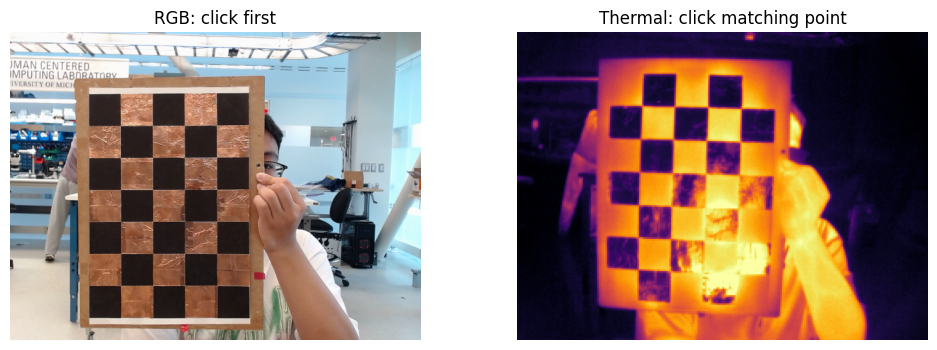

In [6]:
CALIBRATION_OUTPUT = "fixed_homography_thermal_to_rgb.npz"

fixed_calibration = {
    "rgb_points": [],
    "thermal_points": [],
    "H_thermal_to_rgb": None,
    "inlier_mask": None,
}


def _require_capture():
    if captured["rgb"] is None or captured["thermal"] is None:
        raise RuntimeError("Capture a pair first: run Start capture and press b.")
    return captured["rgb"], captured["thermal"]


def _as_plot_rgb(img_bgr):
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) if img_bgr.ndim == 3 else img_bgr


def _draw_picker(axes, rgb_bgr, thermal_bgr):
    for ax in axes:
        ax.clear()
    axes[0].imshow(_as_plot_rgb(rgb_bgr))
    axes[0].set_title("RGB: click first")
    axes[1].imshow(_as_plot_rgb(thermal_bgr))
    axes[1].set_title("Thermal: click matching point")

    rgb_pts = np.asarray(fixed_calibration["rgb_points"], dtype=np.float32)
    th_pts = np.asarray(fixed_calibration["thermal_points"], dtype=np.float32)
    if len(rgb_pts):
        axes[0].scatter(rgb_pts[:, 0], rgb_pts[:, 1], c="lime", s=28)
        for i, (x, y) in enumerate(rgb_pts, start=1):
            axes[0].text(x + 3, y + 3, str(i), color="yellow", fontsize=9)
    if len(th_pts):
        axes[1].scatter(th_pts[:, 0], th_pts[:, 1], c="cyan", s=28)
        for i, (x, y) in enumerate(th_pts, start=1):
            axes[1].text(x + 3, y + 3, str(i), color="white", fontsize=9)

    for ax in axes:
        ax.axis("off")
    axes[0].figure.canvas.draw_idle()


def start_homography_point_picker():
    rgb_bgr, thermal_bgr = _require_capture()
    out = widgets.Output()
    status = widgets.HTML()
    undo_button = widgets.Button(description="Undo pair")
    reset_button = widgets.Button(description="Reset")
    compute_button = widgets.Button(description="Compute H", button_style="primary")
    save_button = widgets.Button(description="Save", button_style="success")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    def set_status(extra=""):
        n_rgb = len(fixed_calibration["rgb_points"])
        n_th = len(fixed_calibration["thermal_points"])
        next_msg = "next: RGB point" if n_rgb == n_th else "next: matching thermal point"
        status.value = f"<b>{n_rgb} RGB / {n_th} thermal points</b> - {next_msg}. {extra}"

    def redraw(extra=""):
        _draw_picker(axes, rgb_bgr, thermal_bgr)
        set_status(extra)

    def on_click(event):
        if event.xdata is None or event.ydata is None:
            return
        x, y = float(event.xdata), float(event.ydata)
        n_rgb = len(fixed_calibration["rgb_points"])
        n_th = len(fixed_calibration["thermal_points"])
        if event.inaxes is axes[0]:
            if n_rgb != n_th:
                redraw("Finish the thermal point for the current pair first.")
                return
            fixed_calibration["rgb_points"].append([x, y])
            redraw(f"Added RGB point {n_rgb + 1}: ({x:.1f}, {y:.1f}).")
        elif event.inaxes is axes[1]:
            if n_rgb <= n_th:
                redraw("Click the RGB point for this pair first.")
                return
            fixed_calibration["thermal_points"].append([x, y])
            redraw(f"Added thermal point {n_th + 1}: ({x:.1f}, {y:.1f}).")

    def undo_pair(_):
        if fixed_calibration["thermal_points"]:
            fixed_calibration["thermal_points"].pop()
        if fixed_calibration["rgb_points"]:
            fixed_calibration["rgb_points"].pop()
        fixed_calibration["H_thermal_to_rgb"] = None
        fixed_calibration["inlier_mask"] = None
        redraw("Removed the last pair.")

    def reset_points(_):
        fixed_calibration["rgb_points"].clear()
        fixed_calibration["thermal_points"].clear()
        fixed_calibration["H_thermal_to_rgb"] = None
        fixed_calibration["inlier_mask"] = None
        redraw("Cleared all points.")

    def compute_h(_):
        with out:
            clear_output(wait=True)
            H, mask, warped = compute_fixed_homography(show=True)
            print("H_thermal_to_rgb =")
            print(H)
            print(f"inliers: {int(mask.sum())}/{len(mask)}")

    def save_h(_):
        with out:
            save_fixed_homography(CALIBRATION_OUTPUT)

    undo_button.on_click(undo_pair)
    reset_button.on_click(reset_points)
    compute_button.on_click(compute_h)
    save_button.on_click(save_h)
    fig.canvas.mpl_connect("button_press_event", on_click)
    redraw()
    display(widgets.HBox([undo_button, reset_button, compute_button, save_button]), status, out)


def compute_fixed_homography(show=True, ransac_reproj_threshold=3.0):
    rgb_bgr, thermal_bgr = _require_capture()
    rgb_pts = np.asarray(fixed_calibration["rgb_points"], dtype=np.float32)
    th_pts = np.asarray(fixed_calibration["thermal_points"], dtype=np.float32)
    if len(rgb_pts) != len(th_pts):
        raise RuntimeError(f"Unpaired points: {len(rgb_pts)} RGB vs {len(th_pts)} thermal.")
    if len(rgb_pts) < 4:
        raise RuntimeError("Need at least 4 point pairs; 12-30 is recommended.")

    H, mask = cv2.findHomography(th_pts, rgb_pts, cv2.RANSAC, ransac_reproj_threshold)
    if H is None:
        raise RuntimeError("cv2.findHomography failed. Check point order and remove bad pairs.")

    fixed_calibration["H_thermal_to_rgb"] = H
    fixed_calibration["inlier_mask"] = mask.reshape(-1).astype(bool)
    warped = cv2.warpPerspective(thermal_bgr, H, (rgb_bgr.shape[1], rgb_bgr.shape[0]))

    if show:
        overlay = cv2.addWeighted(rgb_bgr, 0.55, warped, 0.45, 0)
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        axes[0].imshow(_as_plot_rgb(rgb_bgr))
        axes[0].set_title("RGB")
        axes[1].imshow(_as_plot_rgb(warped))
        axes[1].set_title("Thermal warped to RGB")
        axes[2].imshow(_as_plot_rgb(overlay))
        axes[2].set_title("Overlay")
        for ax in axes:
            ax.axis("off")
        plt.tight_layout()
        plt.show()

    return H, fixed_calibration["inlier_mask"], warped


def save_fixed_homography(path=CALIBRATION_OUTPUT):
    H = fixed_calibration["H_thermal_to_rgb"]
    if H is None:
        H, _, _ = compute_fixed_homography(show=False)
    np.savez_compressed(
        path,
        H_thermal_to_rgb=H,
        rgb_points=np.asarray(fixed_calibration["rgb_points"], dtype=np.float32),
        thermal_points=np.asarray(fixed_calibration["thermal_points"], dtype=np.float32),
        inlier_mask=np.asarray(fixed_calibration["inlier_mask"], dtype=bool),
        rgb_size=np.asarray([captured["rgb"].shape[1], captured["rgb"].shape[0]], dtype=np.int32),
        thermal_size=np.asarray([captured["thermal"].shape[1], captured["thermal"].shape[0]], dtype=np.int32),
    )
    print(f"Saved {path}")


# If clicks do not register, run `%matplotlib widget` in a separate cell, then run this again.
start_homography_point_picker()


In [7]:
# Fallback: paste coordinates directly if clicking does not work.
# Coordinates must be in original image pixels: RGB is usually 640x480; processed thermal is 256x192.
# Keep the same physical points in the same order in both arrays.

fixed_calibration["rgb_points"] = [
    # [x_rgb, y_rgb],
]
fixed_calibration["thermal_points"] = [
    # [x_thermal, y_thermal],
]

# After filling the arrays, run:
# H, inliers, warped = compute_fixed_homography(show=True)
# save_fixed_homography()


## OpenCV point picker fallback

Use this if clicks inside the notebook image do not register. This opens real OpenCV windows, so mouse callbacks work independently of the VS Code/Jupyter matplotlib backend.


Click order: RGB -> matching thermal -> repeat.
Keys: r=set target RGB, t=set target thermal, u=undo pair, c=compute/preview, s=save, q=quit
RGB point 1: (124, 99); now click matching thermal point.
Thermal point 1: (59, 26); now click next RGB point.
RGB point 2: (173, 98); now click matching thermal point.
Thermal point 2: (78, 26); now click next RGB point.
RGB point 3: (225, 98); now click matching thermal point.
Thermal point 3: (99, 26); now click next RGB point.
RGB point 4: (273, 96); now click matching thermal point.
Thermal point 4: (119, 26); now click next RGB point.
RGB point 5: (322, 96); now click matching thermal point.
Thermal point 5: (140, 26); now click next RGB point.
RGB point 6: (124, 147); now click matching thermal point.
Thermal point 6: (58, 46); now click next RGB point.
RGB point 7: (173, 147); now click matching thermal point.
Thermal point 7: (78, 45); now click next RGB point.
RGB point 8: (223, 147); now click matching thermal point.
Thermal point 8: (9

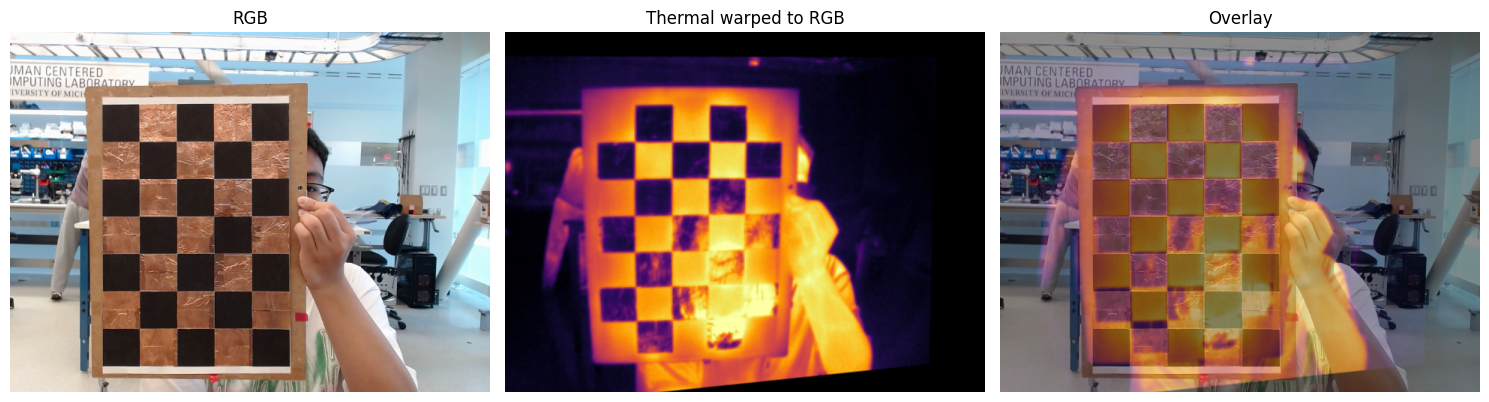

H_thermal_to_rgb =
[[ 2.75541231e+00  1.57809514e-01 -3.64253438e+01]
 [ 2.62024851e-02  2.64464388e+00  3.31842020e+01]
 [ 6.25807744e-04  3.94475162e-04  1.00000000e+00]]
inliers: 16/16
Saved fixed_homography_thermal_to_rgb.npz


In [8]:
def start_cv2_homography_point_picker():
    rgb_bgr, thermal_bgr = _require_capture()
    rgb_view = rgb_bgr.copy()
    thermal_view = thermal_bgr.copy()
    active = {"target": "rgb"}

    def redraw():
        rgb_view[:] = rgb_bgr
        thermal_view[:] = thermal_bgr
        for i, (x, y) in enumerate(fixed_calibration["rgb_points"], start=1):
            p = (int(round(x)), int(round(y)))
            cv2.circle(rgb_view, p, 4, (0, 255, 0), -1)
            cv2.putText(rgb_view, str(i), (p[0] + 5, p[1] - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 255, 255), 1)
        for i, (x, y) in enumerate(fixed_calibration["thermal_points"], start=1):
            p = (int(round(x)), int(round(y)))
            cv2.circle(thermal_view, p, 4, (255, 255, 0), -1)
            cv2.putText(thermal_view, str(i), (p[0] + 5, p[1] - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1)

        rgb_label = f"RGB points: {len(fixed_calibration['rgb_points'])}"
        th_label = f"Thermal points: {len(fixed_calibration['thermal_points'])}"
        cv2.putText(rgb_view, rgb_label, (10, 24), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 255, 0), 2)
        cv2.putText(thermal_view, th_label, (10, 24), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 0), 2)
        cv2.imshow("pick_rgb", rgb_view)
        cv2.imshow("pick_thermal", thermal_view)

    def on_rgb(event, x, y, flags, param):
        if event != cv2.EVENT_LBUTTONDOWN:
            return
        if active["target"] != "rgb":
            print("Current target is thermal. Press r to switch to RGB, or click thermal next.")
            return
        if len(fixed_calibration["rgb_points"]) != len(fixed_calibration["thermal_points"]):
            print("Finish the matching thermal point first.")
            return
        fixed_calibration["rgb_points"].append([float(x), float(y)])
        active["target"] = "thermal"
        print(f"RGB point {len(fixed_calibration['rgb_points'])}: ({x}, {y}); now click matching thermal point.")
        redraw()

    def on_thermal(event, x, y, flags, param):
        if event != cv2.EVENT_LBUTTONDOWN:
            return
        if active["target"] != "thermal":
            print("Current target is RGB. Press t to switch to thermal only if needed.")
            return
        if len(fixed_calibration["rgb_points"]) <= len(fixed_calibration["thermal_points"]):
            print("Click the RGB point first.")
            return
        fixed_calibration["thermal_points"].append([float(x), float(y)])
        active["target"] = "rgb"
        print(f"Thermal point {len(fixed_calibration['thermal_points'])}: ({x}, {y}); now click next RGB point.")
        redraw()

    cv2.namedWindow("pick_rgb", cv2.WINDOW_NORMAL)
    cv2.namedWindow("pick_thermal", cv2.WINDOW_NORMAL)
    cv2.setMouseCallback("pick_rgb", on_rgb)
    cv2.setMouseCallback("pick_thermal", on_thermal)
    redraw()
    print("Click order: RGB -> matching thermal -> repeat.")
    print("Keys: r=set target RGB, t=set target thermal, u=undo pair, c=compute/preview, s=save, q=quit")

    try:
        while True:
            key = cv2.waitKey(50) & 0xFF
            if key == ord("q"):
                break
            if key == ord("r"):
                active["target"] = "rgb"
                print("Target: RGB")
            elif key == ord("t"):
                active["target"] = "thermal"
                print("Target: thermal")
            elif key == ord("u"):
                if fixed_calibration["thermal_points"]:
                    fixed_calibration["thermal_points"].pop()
                if fixed_calibration["rgb_points"]:
                    fixed_calibration["rgb_points"].pop()
                active["target"] = "rgb"
                fixed_calibration["H_thermal_to_rgb"] = None
                fixed_calibration["inlier_mask"] = None
                print("Removed last pair.")
                redraw()
            elif key == ord("c"):
                H, mask, warped = compute_fixed_homography(show=True)
                print("H_thermal_to_rgb =")
                print(H)
                print(f"inliers: {int(mask.sum())}/{len(mask)}")
            elif key == ord("s"):
                save_fixed_homography(CALIBRATION_OUTPUT)
    finally:
        cv2.destroyWindow("pick_rgb")
        cv2.destroyWindow("pick_thermal")


# Run this cell after capturing a pair if notebook clicks do not work.
start_cv2_homography_point_picker()
